# Country-level Economic Freedom Index

The aim is to build one simple country score from raw local data.

The notebook follows a short sequence:
1. choose a small set of interpretable candidate indicators,
2. take the latest available value up to 2024,
3. remove countries and variables that are too weak for a stable index,
4. use correlation, PCA, clustering, and MLR to understand the structure of the data,
5. keep only the blocks that behave consistently,
6. produce one final Economic Freedom Index.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- Global plot style ------------------------------------------------------
sns.set_theme(style="whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

BLOCK_COLORS = {
    "Institutions":       "#1f77b4",
    "Limited Government": "#d62728",
    "Open Markets":       "#2ca02c",
}
REGION_COLORS = {
    "Europe & Central Asia":      "#1f77b4",
    "East Asia & Pacific":        "#2ca02c",
    "North America":              "#17becf",
    "Latin America & Caribbean":  "#ff7f0e",
    "Middle East & North Africa": "#8c564b",
    "South Asia":                 "#9467bd",
    "Sub-Saharan Africa":         "#d62728",
}

TARGET_YEAR = 2024
LOOKBACK_YEARS = [str(year) for year in range(TARGET_YEAR, TARGET_YEAR - 6, -1)]


def percentile_scale(series):
    return series.rank(pct=True) * 100


def add_minor_grid(ax, x_every=None, y_every=None,
                   color="#717171", alpha=0.35,
                   linestyle=(0, (1, 2)), linewidth=0.6):
    """Add subtle minor gridlines at specified intervals.

    Example:
        add_minor_grid(ax, x_every=10)             # x-axis, every 10
        add_minor_grid(ax, x_every=10, y_every=10) # both axes
    """
    if x_every is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(x_every))
        ax.grid(which="minor", axis="x",
                color=color, alpha=alpha,
                linestyle=linestyle, linewidth=linewidth, zorder=0)
    if y_every is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(y_every))
        ax.grid(which="minor", axis="y",
                color=color, alpha=alpha,
                linestyle=linestyle, linewidth=linewidth, zorder=0)
    ax.set_axisbelow(True)


## 1. What the source files mean

Two local data sources are enough for a simple index:

- **WDI** gives country-level economic variables such as trade, inflation, taxes, and government spending.
- **WGI** gives country-level governance scores such as rule of law and regulatory quality.

In this notebook an **indicator** is one raw measurable variable taken from these files.
The index is built from those raw indicators, not from an existing ready-made freedom ranking.

## 2. Start with a broad but still simple candidate set

The first pass should be wider than the final model.
It is easier to start with a few sensible candidates and then remove what the data show to be redundant or unhelpful.

In [2]:
candidate_plan = pd.DataFrame(
    [
        ["rule_of_law", "Rule of law", "rl", "WGI", "Institutions", "Higher is better"],
        ["regulatory_quality", "Regulatory quality", "rq", "WGI", "Institutions", "Higher is better"],
        ["control_of_corruption", "Control of corruption", "cc", "WGI", "Institutions", "Higher is better"],
        ["government_consumption", "Government consumption (% of GDP)", "NE.CON.GOVT.ZS", "WDI", "Limited Government", "Lower is better"],
        ["tax_revenue", "Tax revenue (% of GDP)", "GC.TAX.TOTL.GD.ZS", "WDI", "Limited Government", "Lower is better"],
        ["trade_openness", "Trade (% of GDP)", "NE.TRD.GNFS.ZS", "WDI", "Open Markets", "Higher is better"],
        ["tariff_all_products", "Tariff rate, all products (%)", "TM.TAX.MRCH.SM.AR.ZS", "WDI", "Open Markets", "Lower is better"],
        ["tariff_manufactured", "Tariff rate, manufactured products (%)", "TM.TAX.MANF.SM.AR.ZS", "WDI", "Open Markets", "Lower is better"],
        ["inflation", "Inflation, consumer prices (%)", "FP.CPI.TOTL.ZG", "WDI", "Open Markets", "Lower is better"],
    ],
    columns=["short_name", "plain_name", "indicator_code", "source", "block", "direction"],
)

display(candidate_plan)

,short_name,plain_name,indicator_code,source,block,direction
0,rule_of_law,Rule of law,rl,WGI,Institutions,Higher is better
1,regulatory_quality,Regulatory quality,rq,WGI,Institutions,Higher is better
2,control_of_corruption,Control of corruption,cc,WGI,Institutions,Higher is better
3,government_consumption,Government consumption (% of GDP),NE.CON.GOVT.ZS,WDI,Limited Government,Lower is better
4,tax_revenue,Tax revenue (% of GDP),GC.TAX.TOTL.GD.ZS,WDI,Limited Government,Lower is better
5,trade_openness,Trade (% of GDP),NE.TRD.GNFS.ZS,WDI,Open Markets,Higher is better
6,tariff_all_products,"Tariff rate, all products (%)",TM.TAX.MRCH.SM.AR.ZS,WDI,Open Markets,Lower is better
7,tariff_manufactured,"Tariff rate, manufactured products (%)",TM.TAX.MANF.SM.AR.ZS,WDI,Open Markets,Lower is better
8,inflation,"Inflation, consumer prices (%)",FP.CPI.TOTL.ZG,WDI,Open Markets,Lower is better


## 3. Build one clean country base and choose the time rule

A strict one-year rule is simple, but it throws away a lot of usable information.
For that reason the notebook uses **latest available value up to 2024**.

In [3]:
country_meta = pd.read_csv("WDICountry.csv")
country_meta = country_meta[["Country Code", "Short Name", "Table Name", "Region", "Income Group"]].copy()
country_meta["country_name"] = country_meta["Short Name"].fillna(country_meta["Table Name"])
country_meta = country_meta[country_meta["Region"].notna()].copy()
country_meta = country_meta.rename(
    columns={
        "Country Code": "country_code",
        "Region": "region",
        "Income Group": "income_group",
    }
)
country_meta["income_group"] = country_meta["income_group"].fillna("Not reported in WDICountry.csv")
country_meta = country_meta[["country_code", "country_name", "region", "income_group"]].drop_duplicates("country_code")
country_codes = set(country_meta["country_code"])

wdi_only_codes = candidate_plan.loc[candidate_plan["source"] == "WDI", "indicator_code"].tolist()
coverage_compare_raw = pd.read_csv("WDICSV.csv", usecols=["Country Code", "Indicator Code"] + LOOKBACK_YEARS)
coverage_compare_raw = coverage_compare_raw[
    coverage_compare_raw["Country Code"].isin(country_codes)
    & coverage_compare_raw["Indicator Code"].isin(wdi_only_codes)
].copy()

strict_2024 = coverage_compare_raw[["Country Code", "Indicator Code", "2024"]].dropna()
latest_window = (
    coverage_compare_raw
    .melt(
        id_vars=["Country Code", "Indicator Code"],
        value_vars=LOOKBACK_YEARS,
        var_name="year_used",
        value_name="value",
    )
    .dropna(subset=["value"])
    .sort_values(["Country Code", "Indicator Code", "year_used"], ascending=[True, True, False])
    .drop_duplicates(["Country Code", "Indicator Code"])
)

coverage_compare = pd.DataFrame(
    [
        ["Strict 2024 only", len(strict_2024), strict_2024["Country Code"].nunique()],
        ["Latest available up to 2024", len(latest_window), latest_window["Country Code"].nunique()],
    ],
    columns=["time_rule", "country-indicator pairs kept", "countries covered"],
)

display(coverage_compare)
print("Decision: use the latest available value up to 2024.")


def load_latest_wdi(plan):
    wdi_codes = plan.loc[plan["source"] == "WDI", "indicator_code"].tolist()
    usecols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + LOOKBACK_YEARS
    wdi_raw = pd.read_csv("WDICSV.csv", usecols=usecols)
    wdi_raw = wdi_raw[wdi_raw["Country Code"].isin(country_codes)]
    wdi_raw = wdi_raw[wdi_raw["Indicator Code"].isin(wdi_codes)].copy()

    wdi_long = wdi_raw.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=LOOKBACK_YEARS,
        var_name="year_used",
        value_name="value",
    )
    wdi_long["year_used"] = wdi_long["year_used"].astype(int)
    wdi_long["value"] = pd.to_numeric(wdi_long["value"], errors="coerce")
    wdi_long = wdi_long.dropna(subset=["value"]).copy()
    wdi_long = wdi_long.sort_values(["Country Code", "Indicator Code", "year_used"], ascending=[True, True, False])
    wdi_latest = wdi_long.drop_duplicates(["Country Code", "Indicator Code"]).copy()

    wdi_latest = wdi_latest.rename(
        columns={
            "Country Name": "country_name",
            "Country Code": "country_code",
            "Indicator Code": "indicator_code",
        }
    )
    wdi_latest = wdi_latest.merge(
        plan[["indicator_code", "short_name", "plain_name", "block", "direction", "source"]],
        on="indicator_code",
        how="left",
    )
    return wdi_latest[
        [
            "country_code",
            "country_name",
            "indicator_code",
            "short_name",
            "plain_name",
            "block",
            "direction",
            "source",
            "year_used",
            "value",
        ]
    ]
def load_latest_wgi(plan):
    wgi_plan = plan[plan["source"] == "WGI"].copy()
    frames = []

    for _, row in wgi_plan.iterrows():
        wgi_raw = pd.read_excel(
            "wgidataset_with_sourcedata-2025.xlsx",
            sheet_name=row["indicator_code"],
            usecols=[
                "Economy (name)",
                "Economy (code)",
                "Year",
                "Governance score (0-100)",
            ],
        )
        wgi_raw = wgi_raw.rename(
            columns={
                "Economy (name)": "country_name",
                "Economy (code)": "country_code",
                "Year": "year_used",
                "Governance score (0-100)": "value",
            }
        )
        wgi_raw["country_code"] = wgi_raw["country_code"].replace({"ADO": "AND"})
        wgi_raw = wgi_raw[wgi_raw["country_code"].isin(country_codes)]
        wgi_raw = wgi_raw[wgi_raw["year_used"].between(2019, 2024)].copy()
        wgi_raw = wgi_raw.dropna(subset=["value"]).copy()
        wgi_raw = wgi_raw.sort_values(["country_code", "year_used"], ascending=[True, False])
        wgi_latest = wgi_raw.drop_duplicates("country_code").copy()
        wgi_latest["short_name"] = row["short_name"]
        frames.append(wgi_latest[["country_code", "country_name", "year_used", "value", "short_name"]])

    wgi_latest = pd.concat(frames, ignore_index=True)
    wgi_latest = wgi_latest.merge(
        plan[["short_name", "indicator_code", "plain_name", "block", "direction", "source"]],
        on="short_name",
        how="left",
    )
    return wgi_latest[
        [
            "country_code",
            "country_name",
            "indicator_code",
            "short_name",
            "plain_name",
            "block",
            "direction",
            "source",
            "year_used",
            "value",
        ]
    ]


gdp_plan = pd.DataFrame(
    [
        [
            "gdp_per_capita_ppp",
            "GDP per capita, PPP (current international $)",
            "NY.GDP.PCAP.PP.CD",
            "WDI",
            "Validation only",
            "Higher is better",
        ]
    ],
    columns=["short_name", "plain_name", "indicator_code", "source", "block", "direction"],
)
gdp_latest = load_latest_wdi(gdp_plan)[["country_code", "year_used", "value"]].rename(
    columns={"year_used": "gdp_year_used", "value": "gdp_per_capita_ppp"}
)

print("Countries in the clean country table:", len(country_meta))
print("Countries with GDP data for validation:", gdp_latest["country_code"].nunique())

,time_rule,country-indicator pairs kept,countries covered
0,Strict 2024 only,484,191
1,Latest available up to 2024,1045,204


Decision: use the latest available value up to 2024.
Countries in the clean country table: 217
Countries with GDP data for validation: 199


### Visual comparison of the two time rules

The strict 2024-only rule keeps half as many country-indicator pairs as the rolling 'latest available up to 2024' rule, and covers fewer countries in total.

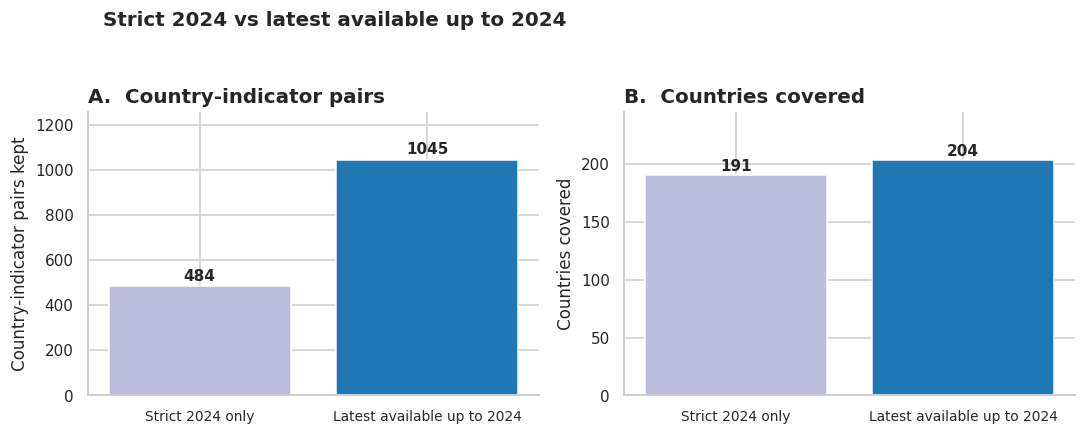

In [4]:
# Figure: strict-2024 vs latest-available time rule
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
_pal = ["#bcbddc", "#1f77b4"]
_b1 = a1.bar(coverage_compare["time_rule"], coverage_compare["country-indicator pairs kept"],
             color=_pal, edgecolor="white")
a1.set_ylabel("Country-indicator pairs kept")
a1.set_title("A.  Country-indicator pairs", loc="left")
a1.set_ylim(0, coverage_compare["country-indicator pairs kept"].max() * 1.2)
for b, v in zip(_b1, coverage_compare["country-indicator pairs kept"]):
    a1.text(b.get_x() + b.get_width() / 2, v + 25, str(v),
            ha="center", fontsize=10, fontweight="bold")
a1.tick_params(axis="x", labelsize=9)

_b2 = a2.bar(coverage_compare["time_rule"], coverage_compare["countries covered"],
             color=_pal, edgecolor="white")
a2.set_ylabel("Countries covered")
a2.set_title("B.  Countries covered", loc="left")
a2.set_ylim(0, coverage_compare["countries covered"].max() * 1.2)
for b, v in zip(_b2, coverage_compare["countries covered"]):
    a2.text(b.get_x() + b.get_width() / 2, v + 3, str(v),
            ha="center", fontsize=10, fontweight="bold")
a2.tick_params(axis="x", labelsize=9)

fig.suptitle("Strict 2024 vs latest available up to 2024",
             fontsize=13, fontweight="bold", x=0.1, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 4. Build the raw master table

At this point the raw files are converted into one visible country-indicator-year table.
This is the main audit table from which the rest of the notebook works.

In [5]:
candidate_wdi_long = load_latest_wdi(candidate_plan)
candidate_wgi_long = load_latest_wgi(candidate_plan)

master_long = pd.concat([candidate_wdi_long, candidate_wgi_long], ignore_index=True)
master_long = master_long.merge(country_meta, on="country_code", how="left", suffixes=("", "_meta"))
master_long["country_name"] = master_long["country_name_meta"].fillna(master_long["country_name"])
master_long = master_long[
    [
        "country_code",
        "country_name",
        "region",
        "income_group",
        "indicator_code",
        "short_name",
        "plain_name",
        "block",
        "direction",
        "source",
        "year_used",
        "value",
    ]
].copy()

print("Rows in the raw master table:", len(master_long))
display(master_long.head(10))

indicator_coverage = (
    master_long.groupby(["short_name", "plain_name", "block", "direction"])
    .agg(
        countries=("country_code", "nunique"),
        earliest_year_used=("year_used", "min"),
        latest_year_used=("year_used", "max"),
    )
    .reset_index()
    .sort_values(["block", "countries"], ascending=[True, False])
)
display(indicator_coverage)

candidate_wide = (
    master_long.pivot_table(
        index=["country_code", "country_name", "region", "income_group"],
        columns="short_name",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

print("Rows in the country-level wide table:", len(candidate_wide))
display(candidate_wide.head(10))

Rows in the raw master table: 1664


,country_code,country_name,region,income_group,indicator_code,short_name,plain_name,block,direction,source,year_used,value
0,ABW,Aruba,Latin America & Caribbean,High income,FP.CPI.TOTL.ZG,inflation,"Inflation, consumer prices (%)",Open Markets,Lower is better,WDI,2019,4.26
1,ABW,Aruba,Latin America & Caribbean,High income,NE.CON.GOVT.ZS,government_consumption,Government consumption (% of GDP),Limited Government,Lower is better,WDI,2024,17.50
2,ABW,Aruba,Latin America & Caribbean,High income,NE.TRD.GNFS.ZS,trade_openness,Trade (% of GDP),Open Markets,Higher is better,WDI,2024,160.37
3,ABW,Aruba,Latin America & Caribbean,High income,TM.TAX.MANF.SM.AR.ZS,tariff_manufactured,"Tariff rate, manufactured products (%)",Open Markets,Lower is better,WDI,2021,10.87
4,ABW,Aruba,Latin America & Caribbean,High income,TM.TAX.MRCH.SM.AR.ZS,tariff_all_products,"Tariff rate, all products (%)",Open Markets,Lower is better,WDI,2021,9.98
5,AFG,Afghanistan,Middle East & North Africa,Low income,FP.CPI.TOTL.ZG,inflation,"Inflation, consumer prices (%)",Open Markets,Lower is better,WDI,2024,-6.60
6,AFG,Afghanistan,Middle East & North Africa,Low income,NE.CON.GOVT.ZS,government_consumption,Government consumption (% of GDP),Limited Government,Lower is better,WDI,2023,21.21
7,AFG,Afghanistan,Middle East & North Africa,Low income,NE.TRD.GNFS.ZS,trade_openness,Trade (% of GDP),Open Markets,Higher is better,WDI,2023,67.58
8,AGO,Angola,Sub-Saharan Africa,Lower middle income,FP.CPI.TOTL.ZG,inflation,"Inflation, consumer prices (%)",Open Markets,Lower is better,WDI,2024,28.24
9,AGO,Angola,Sub-Saharan Africa,Lower middle income,GC.TAX.TOTL.GD.ZS,tax_revenue,Tax revenue (% of GDP),Limited Government,Lower is better,WDI,2024,7.74


,short_name,plain_name,block,direction,countries,earliest_year_used,latest_year_used
0,control_of_corruption,Control of corruption,Institutions,Higher is better,207,2024,2024
4,rule_of_law,Rule of law,Institutions,Higher is better,207,2024,2024
3,regulatory_quality,Regulatory quality,Institutions,Higher is better,205,2024,2024
1,government_consumption,Government consumption (% of GDP),Limited Government,Lower is better,176,2020,2024
7,tax_revenue,Tax revenue (% of GDP),Limited Government,Lower is better,142,2019,2024
2,inflation,"Inflation, consumer prices (%)",Open Markets,Lower is better,184,2019,2024
8,trade_openness,Trade (% of GDP),Open Markets,Higher is better,183,2020,2024
5,tariff_all_products,"Tariff rate, all products (%)",Open Markets,Lower is better,180,2019,2022
6,tariff_manufactured,"Tariff rate, manufactured products (%)",Open Markets,Lower is better,180,2019,2022


Rows in the country-level wide table: 210


short_name,country_code,country_name,region,income_group,control_of_corruption,government_consumption,inflation,regulatory_quality,rule_of_law,tariff_all_products,tariff_manufactured,tax_revenue,trade_openness
0,ABW,Aruba,Latin America & Caribbean,High income,65.44,17.50,4.26,70.33,77.96,9.98,10.87,NaN,160.37
1,AFG,Afghanistan,Middle East & North Africa,Low income,21.36,21.21,-6.60,30.60,23.65,NaN,NaN,NaN,67.58
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,35.25,10.68,28.24,42.67,36.83,11.59,10.19,7.74,50.84
3,ALB,Albania,Europe & Central Asia,Upper middle income,39.34,12.42,2.22,57.00,54.93,0.57,0.40,17.80,79.45
4,AND,Andorra,Europe & Central Asia,High income,71.66,NaN,NaN,72.24,81.23,NaN,NaN,13.95,NaN
5,ARE,United Arab Emirates,Middle East & North Africa,High income,71.54,12.22,1.66,72.62,65.52,4.11,4.00,0.65,199.04
6,ARG,Argentina,Latin America & Caribbean,Upper middle income,41.26,14.92,219.88,51.16,52.64,11.95,12.35,9.93,27.93
7,ARM,Armenia,Europe & Central Asia,Upper middle income,50.78,10.66,0.27,57.04,54.51,5.70,5.57,22.37,150.06
8,ASM,American Samoa,East Asia & Pacific,High income,71.66,NaN,NaN,61.04,75.67,NaN,NaN,NaN,124.68
9,ATG,Antigua and Barbuda,Latin America & Caribbean,High income,53.61,NaN,6.20,64.87,67.32,12.39,11.51,NaN,117.70


### How much of the world is actually covered?

For each candidate indicator, how many of the 217 country entities have at least one observation in the 2019-2024 window?  `tax_revenue` is the weakest and `rule_of_law` / `control_of_corruption` the strongest.

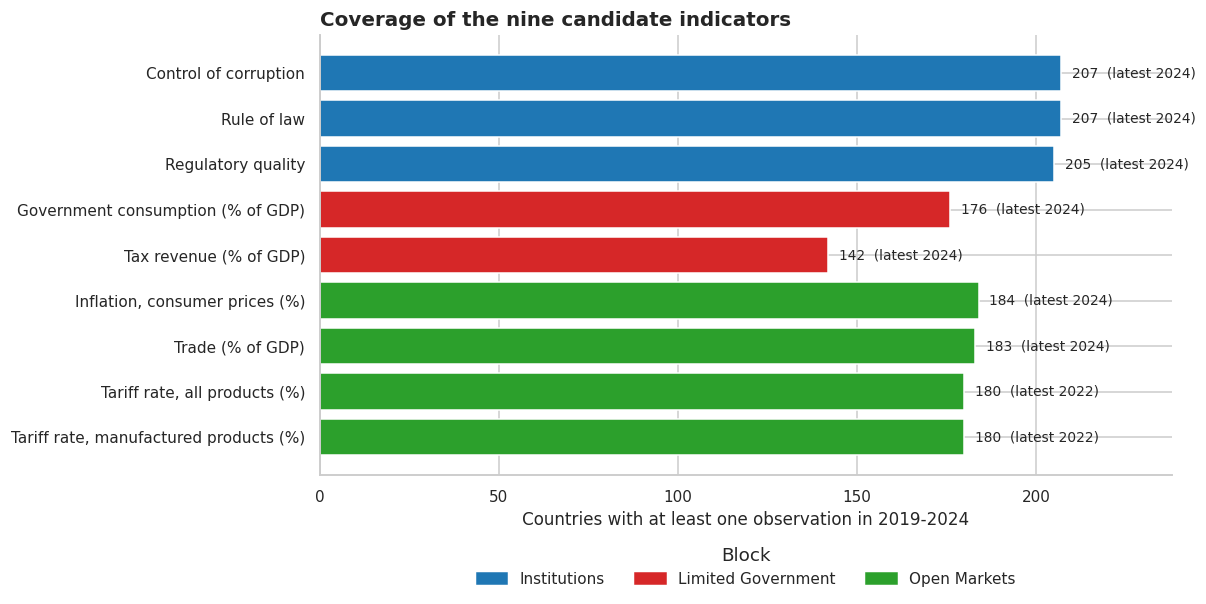

In [6]:
# Figure: coverage of the nine candidate indicators
# (runs once the indicator_coverage DataFrame exists in Cell 8)
fig, ax = plt.subplots(figsize=(10, 5.2))
_plot_df = (
    indicator_coverage
    .merge(candidate_plan[["short_name", "plain_name"]], on=["short_name", "plain_name"], how="left")
    .sort_values(["block", "countries"], ascending=[True, False])
    .reset_index(drop=True)
)
colors = [BLOCK_COLORS[b] for b in _plot_df["block"]]
bars = ax.barh(_plot_df["plain_name"], _plot_df["countries"], color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Countries with at least one observation in 2019-2024")
ax.set_title("Coverage of the nine candidate indicators", loc="left")
ax.set_xlim(0, _plot_df["countries"].max() * 1.15)
for bar, val, yr in zip(bars, _plot_df["countries"], _plot_df["latest_year_used"]):
    ax.text(val + 3, bar.get_y() + bar.get_height() / 2,
            f"{val}  (latest {yr})", va="center", fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in BLOCK_COLORS.values()]
ax.legend(handles, BLOCK_COLORS.keys(),
          loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=3, title="Block", frameon=False)
plt.show()


## 5. Remove variables that are clearly saying almost the same thing

Very high correlation is a warning sign.
If two indicators are almost the same signal, keeping both would count the same idea twice.

In [7]:
directed_candidate = candidate_wide[["country_code", "country_name"]].copy()
candidate_columns = candidate_plan["short_name"].tolist()

for _, row in candidate_plan.iterrows():
    series = candidate_wide[row["short_name"]].copy()
    if row["direction"] == "Lower is better":
        series = -series
    directed_candidate[row["short_name"]] = series

directed_corr = directed_candidate[candidate_columns].corr().round(3)
display(directed_corr)

high_corr_pairs = []
for left_position, left_name in enumerate(candidate_columns):
    for right_name in candidate_columns[left_position + 1 :]:
        corr_value = directed_corr.loc[left_name, right_name]
        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                {
                    "left_indicator": left_name,
                    "right_indicator": right_name,
                    "correlation": corr_value,
                }
            )

high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values("correlation", ascending=False).reset_index(drop=True)
display(high_corr_pairs)

print("Decision 1: drop control_of_corruption because it is almost the same signal as rule_of_law.")
print("Decision 2: drop tariff_manufactured because it is almost the same signal as tariff_all_products.")

selected_plan = candidate_plan[
    ~candidate_plan["short_name"].isin(["control_of_corruption", "tariff_manufactured"])
].copy().reset_index(drop=True)

display(selected_plan)

short_name,rule_of_law,regulatory_quality,control_of_corruption,government_consumption,tax_revenue,trade_openness,tariff_all_products,tariff_manufactured,inflation
short_name,,,,,,,,,
rule_of_law,1.00,0.91,0.95,-0.31,-0.47,0.39,0.43,0.45,0.26
regulatory_quality,0.91,1.00,0.90,-0.16,-0.41,0.43,0.53,0.55,0.27
control_of_corruption,0.95,0.90,1.00,-0.27,-0.42,0.40,0.40,0.42,0.26
government_consumption,-0.31,-0.16,-0.27,1.00,0.42,-0.15,-0.34,-0.33,-0.11
tax_revenue,-0.47,-0.41,-0.42,0.42,1.00,-0.26,-0.32,-0.33,-0.14
trade_openness,0.39,0.43,0.40,-0.15,-0.26,1.00,0.38,0.37,0.23
tariff_all_products,0.43,0.53,0.40,-0.34,-0.32,0.38,1.00,0.98,0.14
tariff_manufactured,0.45,0.55,0.42,-0.33,-0.33,0.37,0.98,1.00,0.14
inflation,0.26,0.27,0.26,-0.11,-0.14,0.23,0.14,0.14,1.00


,left_indicator,right_indicator,correlation
0,tariff_all_products,tariff_manufactured,0.98
1,rule_of_law,control_of_corruption,0.95
2,rule_of_law,regulatory_quality,0.91


Decision 1: drop control_of_corruption because it is almost the same signal as rule_of_law.
Decision 2: drop tariff_manufactured because it is almost the same signal as tariff_all_products.


,short_name,plain_name,indicator_code,source,block,direction
0,rule_of_law,Rule of law,rl,WGI,Institutions,Higher is better
1,regulatory_quality,Regulatory quality,rq,WGI,Institutions,Higher is better
2,government_consumption,Government consumption (% of GDP),NE.CON.GOVT.ZS,WDI,Limited Government,Lower is better
3,tax_revenue,Tax revenue (% of GDP),GC.TAX.TOTL.GD.ZS,WDI,Limited Government,Lower is better
4,trade_openness,Trade (% of GDP),NE.TRD.GNFS.ZS,WDI,Open Markets,Higher is better
5,tariff_all_products,"Tariff rate, all products (%)",TM.TAX.MRCH.SM.AR.ZS,WDI,Open Markets,Lower is better
6,inflation,"Inflation, consumer prices (%)",FP.CPI.TOTL.ZG,WDI,Open Markets,Lower is better


### Correlation heatmap and duplicate pairs

The table above is easier to read as a heatmap.  The chart below it highlights the indicator pairs that exceed the 0.90 redundancy threshold (the two duplicates that are removed).

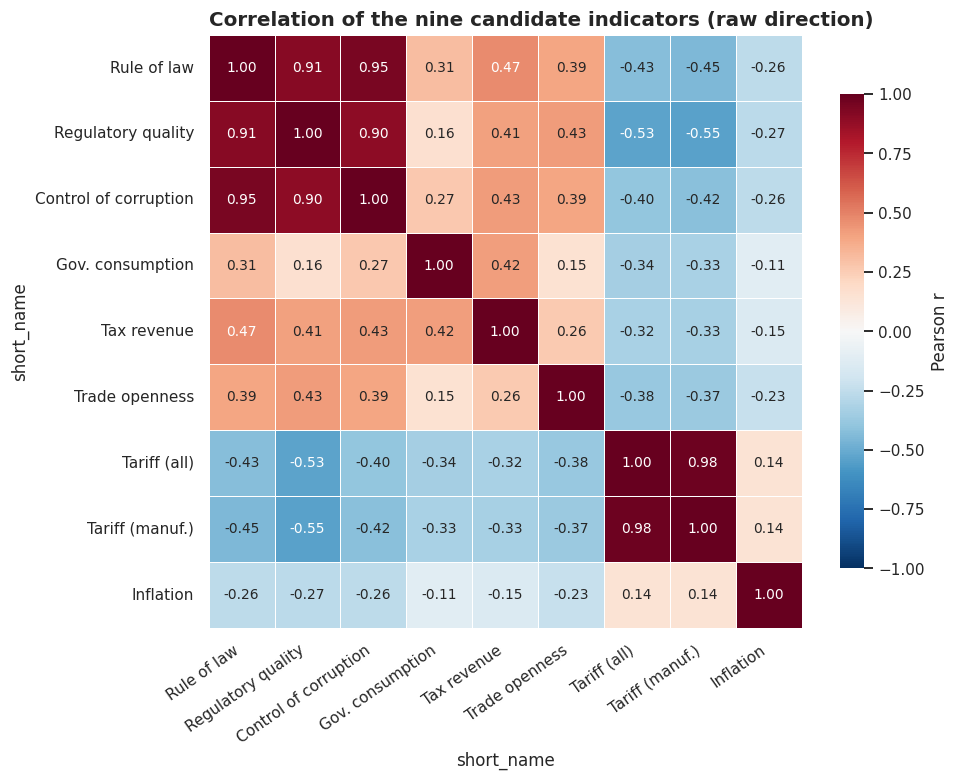

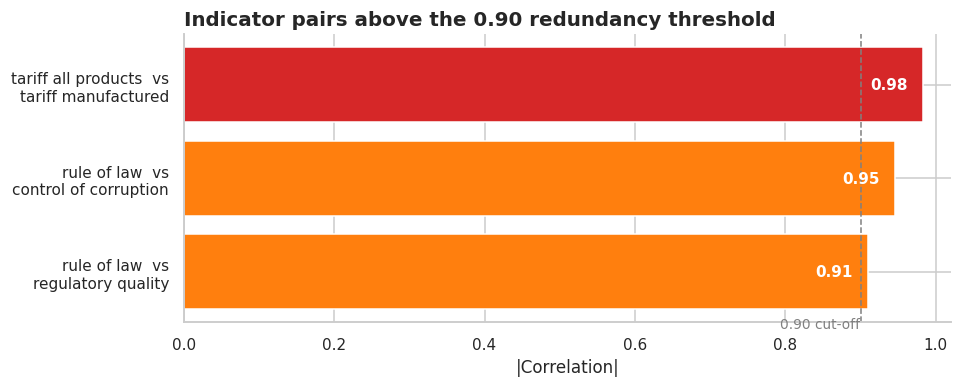

In [8]:
# Figure: correlation heatmap (much easier to read than the raw table above)
_nice = {
    "rule_of_law":            "Rule of law",
    "regulatory_quality":     "Regulatory quality",
    "control_of_corruption":  "Control of corruption",
    "government_consumption": "Gov. consumption",
    "tax_revenue":            "Tax revenue",
    "trade_openness":         "Trade openness",
    "tariff_all_products":    "Tariff (all)",
    "tariff_manufactured":    "Tariff (manuf.)",
    "inflation":              "Inflation",
}
_raw_corr = candidate_wide[candidate_plan["short_name"].tolist()].corr()
_raw_corr = _raw_corr.rename(index=_nice, columns=_nice)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(_raw_corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=.5, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": .8}, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Correlation of the nine candidate indicators (raw direction)", loc="left")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.show()

# Figure: duplicate pairs above the 0.90 threshold
if len(high_corr_pairs):
    _dup = high_corr_pairs.copy()
    _dup["label"] = _dup["left_indicator"].str.replace("_", " ") + "  vs\n" + \
                    _dup["right_indicator"].str.replace("_", " ")
    fig, ax = plt.subplots(figsize=(9, 3.4))
    _colors = ["#d62728" if v >= 0.95 else "#ff7f0e" for v in _dup["correlation"]]
    _bars = ax.barh(_dup["label"], _dup["correlation"].abs(), color=_colors, edgecolor="white")
    ax.axvline(0.90, color="grey", linestyle="--", linewidth=1)
    ax.text(0.90, len(_dup) - 0.4, "0.90 cut-off", color="grey", fontsize=9, ha="right")
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("|Correlation|")
    ax.invert_yaxis()
    for b, v in zip(_bars, _dup["correlation"].abs()):
        ax.text(v - 0.02, b.get_y() + b.get_height() / 2, f"{v:.2f}",
                va="center", ha="right", color="white", fontsize=10, fontweight="bold")
    ax.set_title("Indicator pairs above the 0.90 redundancy threshold", loc="left")
    plt.show()


## 6. Build a provisional three-block version before deciding on the final index

After removing the obvious duplicates, the notebook keeps three provisional blocks:

- **Institutions**: rule of law and regulatory quality
- **Limited Government**: government consumption and tax revenue
- **Open Markets**: trade, tariffs, and inflation

This is still not the final index.
It is a diagnostic stage used to check whether the blocks behave as expected.

In [9]:
selected_columns = ["country_code", "country_name", "region", "income_group"] + selected_plan["short_name"].tolist()
selected_data = candidate_wide[selected_columns].copy()

selected_data["institutions_count"] = selected_data[["rule_of_law", "regulatory_quality"]].notna().sum(axis=1)
selected_data["limited_government_count"] = selected_data[["government_consumption", "tax_revenue"]].notna().sum(axis=1)
selected_data["open_markets_count"] = selected_data[["trade_openness", "tariff_all_products", "inflation"]].notna().sum(axis=1)

diagnostic_mask = (
    (selected_data["institutions_count"] >= 2)
    & (selected_data["limited_government_count"] >= 1)
    & (selected_data["open_markets_count"] >= 2)
)
diagnostic_data = selected_data.loc[diagnostic_mask].copy().reset_index(drop=True)
dropped_diagnostic = selected_data.loc[
    ~diagnostic_mask,
    ["country_code", "country_name", "institutions_count", "limited_government_count", "open_markets_count"],
].copy()

sample_summary = pd.DataFrame(
    [
        ["All countries in the clean country table", len(selected_data)],
        ["Countries kept for three-block diagnostics", len(diagnostic_data)],
        ["Countries dropped at this stage", len(dropped_diagnostic)],
    ],
    columns=["sample_step", "country_count"],
)
display(sample_summary)
display(dropped_diagnostic.head(10))

diagnostic_missing_before_fill = (
    diagnostic_data[selected_plan["short_name"].tolist()]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "short_name", 0: "missing_before_fill"})
)
display(diagnostic_missing_before_fill)

for column in selected_plan["short_name"]:
    diagnostic_data[column] = diagnostic_data[column].fillna(diagnostic_data[column].median())

diagnostic_scores = diagnostic_data[["country_code", "country_name", "region", "income_group"]].copy()
for _, row in selected_plan.iterrows():
    series = diagnostic_data[row["short_name"]].copy()
    if row["direction"] == "Lower is better":
        series = -series
    diagnostic_scores[row["short_name"]] = percentile_scale(series)

diagnostic_scores["Institutions"] = diagnostic_scores[["rule_of_law", "regulatory_quality"]].mean(axis=1)
diagnostic_scores["Limited Government"] = diagnostic_scores[["government_consumption", "tax_revenue"]].mean(axis=1)
diagnostic_scores["Open Markets"] = diagnostic_scores[["trade_openness", "tariff_all_products", "inflation"]].mean(axis=1)

display(
    diagnostic_scores[
        [
            "country_code",
            "country_name",
            "Institutions",
            "Limited Government",
            "Open Markets",
        ]
    ].head(10)
)

,sample_step,country_count
0,All countries in the clean country table,210
1,Countries kept for three-block diagnostics,177
2,Countries dropped at this stage,33


short_name,country_code,country_name,institutions_count,limited_government_count,open_markets_count
4,AND,Andorra,2,1,0
8,ASM,American Samoa,2,0,1
9,ATG,Antigua and Barbuda,2,0,3
27,BRB,Barbados,2,0,2
45,CUW,Curaçao,0,0,1
51,DMA,Dominica,2,0,2
57,ERI,Eritrea,2,0,0
64,FRO,Faroe Islands,0,1,1
75,GRD,Grenada,2,0,2
76,GRL,Greenland,2,1,1


,short_name,missing_before_fill
0,rule_of_law,0
1,regulatory_quality,0
2,government_consumption,9
3,tax_revenue,38
4,trade_openness,8
5,tariff_all_products,10
6,inflation,6


short_name,country_code,country_name,Institutions,Limited Government,Open Markets
0,ABW,Aruba,85.88,45.48,51.98
1,AFG,Afghanistan,1.41,34.46,61.96
2,AGO,Angola,15.82,88.14,16.76
3,ALB,Albania,57.34,53.67,70.06
4,ARE,United Arab Emirates,77.68,88.14,78.72
5,ARG,Argentina,45.20,74.01,8.29
6,ARM,Armenia,57.34,50.56,77.40
7,AUS,Australia,93.79,13.28,47.08
8,AUT,Austria,92.94,14.69,70.53
9,AZE,Azerbaijan,49.44,48.59,52.35


### Missing-value diagnostic

Before the median imputation is applied, this is the picture of how much data is actually missing per indicator in the diagnostic sample.  The Limited-Government block is the weakest, with `tax_revenue` missing for a large share of countries.

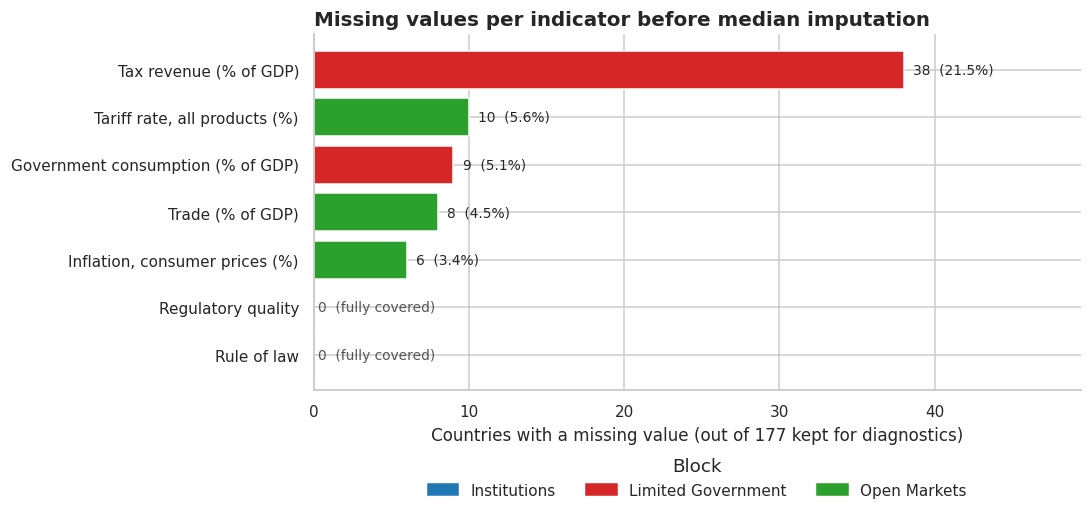

In [10]:
# Figure: missing values per indicator in the 177-country diagnostic sample
_miss = diagnostic_missing_before_fill.merge(
    selected_plan[["short_name", "block", "plain_name"]], on="short_name", how="left"
).sort_values("missing_before_fill", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
_colors = [BLOCK_COLORS[b] for b in _miss["block"]]
_bars = ax.barh(_miss["plain_name"], _miss["missing_before_fill"],
                color=_colors, edgecolor="white")
_n = len(diagnostic_data)
for b, v in zip(_bars, _miss["missing_before_fill"]):
    if v == 0:
        ax.text(0.3, b.get_y() + b.get_height() / 2,
                "0  (fully covered)", va="center", fontsize=9, color="#555")
    else:
        ax.text(v + 0.6, b.get_y() + b.get_height() / 2,
                f"{v}  ({100 * v / _n:.1f}%)", va="center", fontsize=9)
ax.set_xlabel(f"Countries with a missing value (out of {_n} kept for diagnostics)")
ax.set_xlim(0, max(5, _miss["missing_before_fill"].max() * 1.3))
ax.set_title("Missing values per indicator before median imputation", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in BLOCK_COLORS.values()]
ax.legend(handles, BLOCK_COLORS.keys(),
          loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=3, title="Block", frameon=False)
plt.show()


## 7. PCA on the provisional blocks

PCA is used here as a diagnostic tool.
The main question is simple: do the provisional blocks move together as one common freedom pattern, or does one block move in a different direction?

,principal_component,explained_variance_ratio
0,PC1,0.66
1,PC2,0.21
2,PC3,0.13


,block,PC1,PC2,PC3
0,Institutions,0.60,0.36,0.71
1,Limited Government,-0.53,0.85,0.02
2,Open Markets,0.60,0.39,-0.70


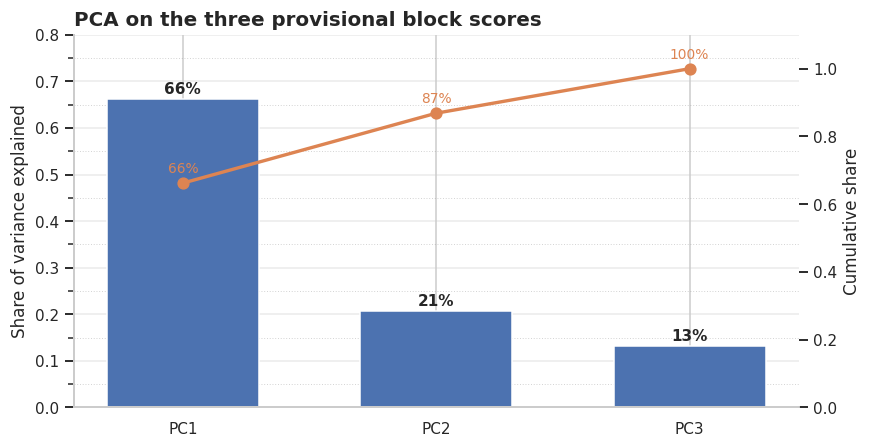

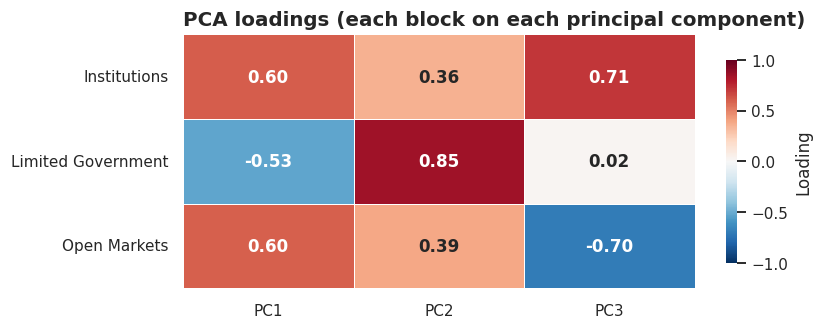

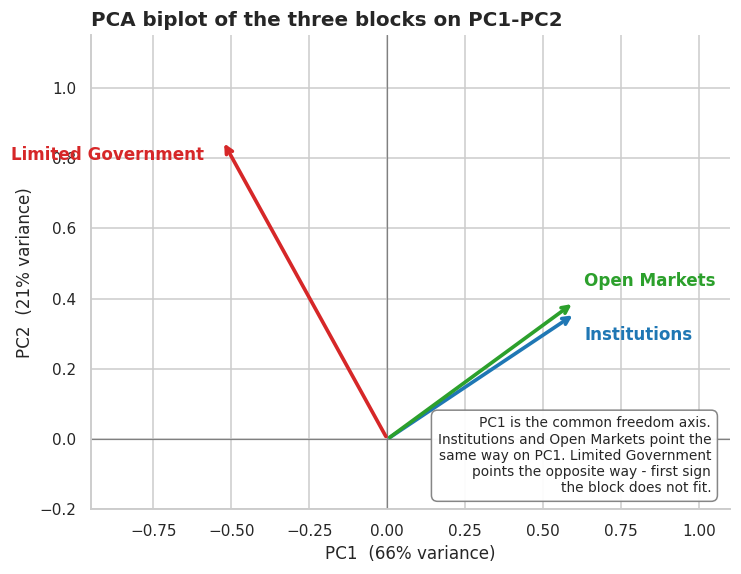

In [11]:
block_columns = ["Institutions", "Limited Government", "Open Markets"]

block_standard = pd.DataFrame(
    StandardScaler().fit_transform(diagnostic_scores[block_columns]),
    columns=block_columns,
    index=diagnostic_scores.index,
)

block_pca = PCA()
block_components = block_pca.fit_transform(block_standard)

block_pca_variance = pd.DataFrame(
    {
        "principal_component": ["PC1", "PC2", "PC3"],
        "explained_variance_ratio": block_pca.explained_variance_ratio_,
    }
)
block_pca_loadings = (
    pd.DataFrame(
        block_pca.components_.T,
        index=block_columns,
        columns=["PC1", "PC2", "PC3"],
    )
    .reset_index()
    .rename(columns={"index": "block"})
)

display(block_pca_variance)
display(block_pca_loadings[["block", "PC1", "PC2", "PC3"]])

# ---- Improved PCA visualisations --------------------------------------------

# Variance + cumulative line
_var = block_pca_variance.copy()
_var["cumulative"] = _var["explained_variance_ratio"].cumsum()

fig, ax = plt.subplots(figsize=(8.5, 4.4))
_b = ax.bar(_var["principal_component"], _var["explained_variance_ratio"],
            color="#4c72b0", edgecolor="white", width=0.6)
for b, v in zip(_b, _var["explained_variance_ratio"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012,
            f"{v:.0%}", ha="center", fontsize=10, fontweight="bold")
ax2 = ax.twinx()
ax2.plot(_var["principal_component"], _var["cumulative"], "-o",
         color="#dd8452", linewidth=2.2, markersize=7, label="Cumulative")
for x, y in zip(_var["principal_component"], _var["cumulative"]):
    ax2.text(x, y + 0.03, f"{y:.0%}", ha="center", fontsize=9, color="#dd8452")
ax.set_ylim(0, 0.8)
ax2.set_ylim(0, 1.1)
ax.set_ylabel("Share of variance explained")
ax2.set_ylabel("Cumulative share")
ax.grid(axis="y", alpha=.4)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax.set_title("PCA on the three provisional block scores", loc="left")
add_minor_grid(ax, y_every=0.05)
plt.show()

# Loadings heatmap
_L = block_pca_loadings.set_index("block")[["PC1", "PC2", "PC3"]]
fig, ax = plt.subplots(figsize=(7.5, 3.0))
sns.heatmap(_L, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=.5, linecolor="white",
            cbar_kws={"label": "Loading", "shrink": .8},
            annot_kws={"size": 11, "weight": "bold"}, ax=ax)
ax.set_title("PCA loadings (each block on each principal component)", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

# Biplot – PC1 / PC2
fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.axhline(0, color="grey", linewidth=.8)
ax.axvline(0, color="grey", linewidth=.8)
_labels = {"Institutions": (0.03, -0.06),
           "Open Markets": (0.03,  0.06),
           "Limited Government": (-0.06, -0.04)}
_ha = {"Institutions": "left", "Open Markets": "left", "Limited Government": "right"}
for block in _L.index:
    pc1, pc2 = _L.loc[block, "PC1"], _L.loc[block, "PC2"]
    ax.annotate("", xy=(pc1, pc2), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=BLOCK_COLORS[block], lw=2.4))
    ox, oy = _labels[block]
    ax.text(pc1 + ox, pc2 + oy, block, color=BLOCK_COLORS[block],
            fontsize=11, fontweight="bold", ha=_ha[block], va="center")

_pc1v = block_pca_variance.loc[0, "explained_variance_ratio"]
_pc2v = block_pca_variance.loc[1, "explained_variance_ratio"]
ax.set_xlim(-0.95, 1.1)
ax.set_ylim(-0.2, 1.15)
ax.set_xlabel(f"PC1  ({_pc1v:.0%} variance)")
ax.set_ylabel(f"PC2  ({_pc2v:.0%} variance)")
ax.set_title("PCA biplot of the three blocks on PC1-PC2", loc="left")
ax.text(0.97, 0.03,
        "PC1 is the common freedom axis.\n"
        "Institutions and Open Markets point the\n"
        "same way on PC1. Limited Government\n"
        "points the opposite way - first sign\n"
        "the block does not fit.",
        transform=ax.transAxes, va="bottom", ha="right",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.45",
                              facecolor="white", edgecolor="grey", alpha=.95))
plt.show()


## 8. Clustering on the provisional blocks

Clustering is used to see whether countries naturally split into groups with similar profiles.

,k,silhouette_score
0,2,0.40
1,4,0.32
2,3,0.32


Best silhouette score is at k = 2. This is the clustering used below.


short_name,Institutions,Limited Government,Open Markets
cluster_name,,,
Higher freedom,68.97,36.15,63.80
Lower freedom,26.56,68.22,33.12


short_name,country_name,cluster_name
0,Albania,Higher freedom
1,Armenia,Higher freedom
2,Aruba,Higher freedom
3,Australia,Higher freedom
4,Austria,Higher freedom
5,Azerbaijan,Higher freedom
6,Afghanistan,Lower freedom
7,Algeria,Lower freedom
8,Angola,Lower freedom
9,Argentina,Lower freedom


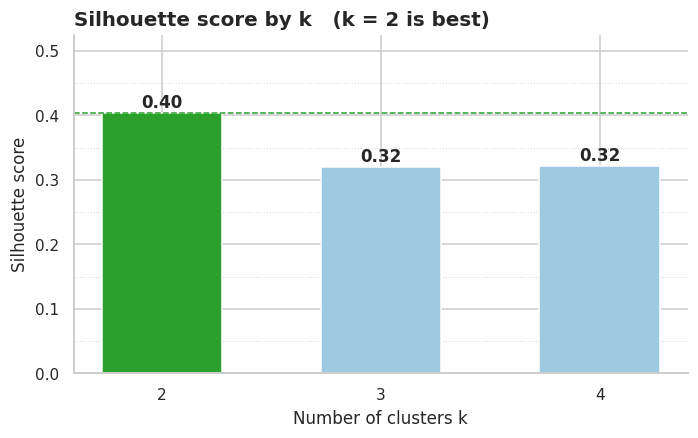

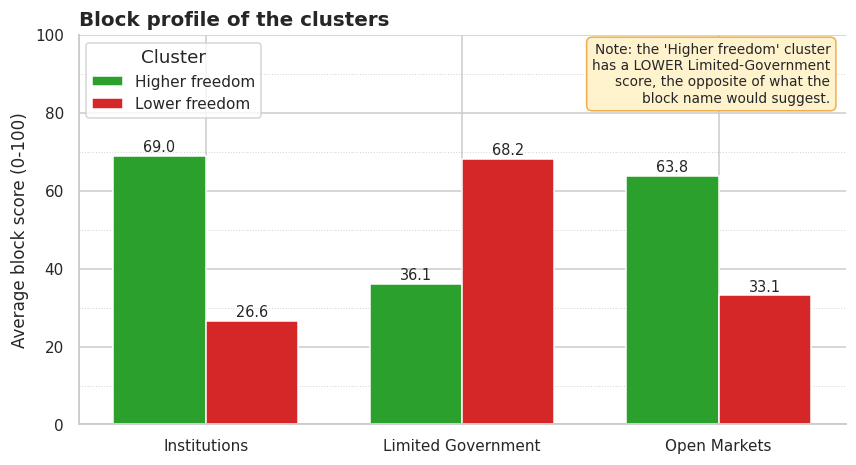

In [18]:
clustering_diagnostics = []
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(block_standard)
    clustering_diagnostics.append(
        {
            "k": k,
            "silhouette_score": silhouette_score(block_standard, labels),
        }
    )

clustering_diagnostics = pd.DataFrame(clustering_diagnostics).sort_values("silhouette_score", ascending=False).reset_index(drop=True)
display(clustering_diagnostics)

best_k = int(clustering_diagnostics.loc[0, "k"])
print(f"Best silhouette score is at k = {best_k}. This is the clustering used below.")

cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
diagnostic_scores["cluster_id"] = cluster_model.fit_predict(block_standard)
diagnostic_scores["average_block_score"] = diagnostic_scores[block_columns].mean(axis=1)

cluster_order = (
    diagnostic_scores.groupby("cluster_id")["average_block_score"]
    .mean()
    .sort_values()
    .index
    .tolist()
)
if best_k == 2:
    ordered_names = ["Lower freedom", "Higher freedom"]
elif best_k == 3:
    ordered_names = ["Lower freedom", "Middle freedom", "Higher freedom"]
else:
    ordered_names = [f"Cluster {position}" for position in range(1, best_k + 1)]

cluster_name_map = {cluster_id: name for cluster_id, name in zip(cluster_order, ordered_names)}
diagnostic_scores["cluster_name"] = diagnostic_scores["cluster_id"].map(cluster_name_map)

cluster_profile = diagnostic_scores.groupby("cluster_name")[block_columns].mean().round(2)
display(cluster_profile)

cluster_examples = (
    diagnostic_scores[["country_name", "cluster_name"]]
    .sort_values(["cluster_name", "country_name"])
    .groupby("cluster_name")
    .head(6)
    .reset_index(drop=True)
)
display(cluster_examples)

# ---- Silhouette comparison ---------------------------------------------------
_cd = clustering_diagnostics.sort_values("k")
fig, ax = plt.subplots(figsize=(7.2, 4))
_colors = ["#2ca02c" if k == best_k else "#9ecae1" for k in _cd["k"]]
_bars = ax.bar(_cd["k"].astype(str), _cd["silhouette_score"],
               color=_colors, edgecolor="white", width=0.55)
for b, v in zip(_bars, _cd["silhouette_score"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008,
            f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Silhouette score")
ax.set_ylim(0, max(0.5, _cd["silhouette_score"].max() * 1.3))
_best = _cd["silhouette_score"].max()
ax.axhline(_best, color="#2ca02c", linestyle="--", linewidth=1)
ax.set_title(f"Silhouette score by k   (k = {best_k} is best)", loc="left")
add_minor_grid(ax, y_every=0.05)
plt.show()

# ---- Cluster profile ---------------------------------------------------------
_cp = cluster_profile.reset_index()
_blocks = ["Institutions", "Limited Government", "Open Markets"]
x = np.arange(len(_blocks))
w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.6))
# Sort so that higher-freedom is plotted first if present
if "Higher freedom" in _cp["cluster_name"].values and "Lower freedom" in _cp["cluster_name"].values:
    _hi = _cp[_cp["cluster_name"] == "Higher freedom"].iloc[0]
    _lo = _cp[_cp["cluster_name"] == "Lower freedom"].iloc[0]
    _bars1 = ax.bar(x - w/2, [_hi[b] for b in _blocks], width=w,
                    label="Higher freedom", color="#2ca02c", edgecolor="white")
    _bars2 = ax.bar(x + w/2, [_lo[b] for b in _blocks], width=w,
                    label="Lower freedom", color="#d62728", edgecolor="white")
    for bb in (_bars1, _bars2):
        for b in bb:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                    f"{b.get_height():.1f}", ha="center", fontsize=9.5)
    ax.text(0.98, 0.98,
            "Note: the 'Higher freedom' cluster\n"
            "has a LOWER Limited-Government\n"
            "score, the opposite of what the\n"
            "block name would suggest.",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="#fff3cd", edgecolor="#f0ad4e"))
else:
    # Generic multi-cluster fallback
    _palette = sns.color_palette("Set2", n_colors=len(_cp))
    for i, (_, row) in enumerate(_cp.iterrows()):
        offset = (i - (len(_cp) - 1) / 2) * (w / len(_cp) * 2)
        _bb = ax.bar(x + offset, [row[b] for b in _blocks], width=w / len(_cp) * 1.6,
                     label=row["cluster_name"], color=_palette[i], edgecolor="white")
        for b in _bb:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                    f"{b.get_height():.1f}", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(_blocks)
ax.set_ylabel("Average block score (0-100)")
ax.set_ylim(0, 100)
ax.set_title("Block profile of the clusters", loc="left")
ax.legend(title="Cluster", frameon=True, facecolor="white")
add_minor_grid(ax, y_every=10)
plt.show()


## 9. MLR as an external check

GDP per capita PPP is **not** used as an input to the index.
It is used only as an external check.

Block-level MLR R-squared: 0.6571


,block,coefficient
0,Institutions,0.71
2,Open Markets,0.23
1,Limited Government,0.13


,block,VIF
0,Institutions,1.70
2,Open Markets,1.67
1,Limited Government,1.31


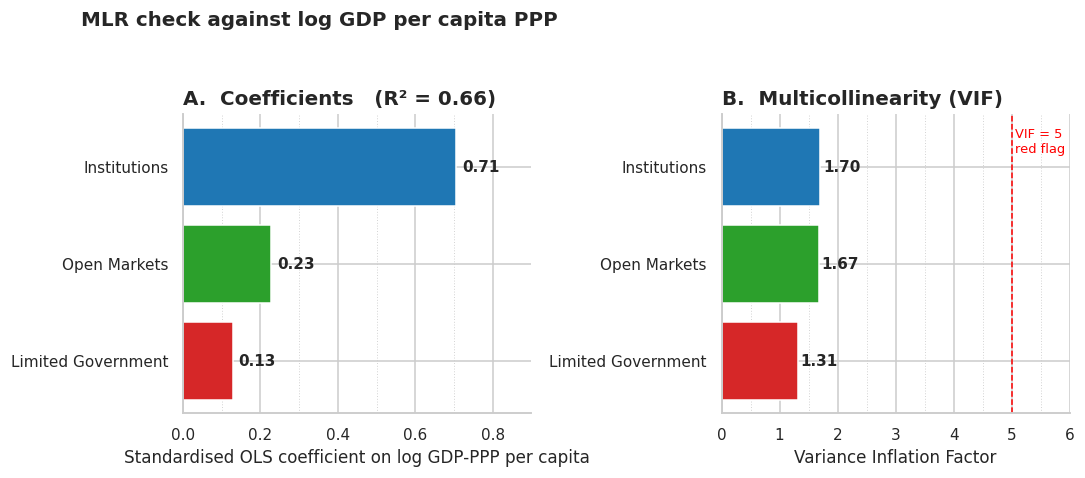

In [13]:
block_regression = diagnostic_scores[["country_code"] + block_columns].merge(
    gdp_latest[["country_code", "gdp_per_capita_ppp"]],
    on="country_code",
    how="inner",
)
block_regression["log_gdp_per_capita_ppp"] = np.log(block_regression["gdp_per_capita_ppp"])

X_block = pd.DataFrame(
    StandardScaler().fit_transform(block_regression[block_columns]),
    columns=block_columns,
    index=block_regression.index,
)
y_block = pd.Series(
    StandardScaler().fit_transform(block_regression[["log_gdp_per_capita_ppp"]]).ravel(),
    index=block_regression.index,
)

block_mlr_model = sm.OLS(y_block, sm.add_constant(X_block)).fit()

block_coefficient_table = pd.DataFrame(
    {
        "block": block_columns,
        "coefficient": block_mlr_model.params.iloc[1:].values,
    }
).sort_values("coefficient", ascending=False)

block_vif_table = pd.DataFrame(
    {
        "block": block_columns,
        "VIF": [variance_inflation_factor(X_block.values, i) for i in range(X_block.shape[1])],
    }
).sort_values("VIF", ascending=False)

print("Block-level MLR R-squared:", round(block_mlr_model.rsquared, 4))
display(block_coefficient_table)
display(block_vif_table)

# Figure: MLR coefficients and VIF side by side
_coef = block_coefficient_table.sort_values("coefficient", ascending=True).reset_index(drop=True)
_vif = block_vif_table.set_index("block").loc[_coef["block"]].reset_index()

fig, axs = plt.subplots(1, 2, figsize=(10, 4.4))
_colors = [BLOCK_COLORS[b] for b in _coef["block"]]
_b = axs[0].barh(_coef["block"], _coef["coefficient"], color=_colors, edgecolor="white")
for b, v in zip(_b, _coef["coefficient"]):
    axs[0].text(v + 0.015, b.get_y() + b.get_height()/2,
                f"{v:.2f}", va="center", fontsize=10, fontweight="bold")
axs[0].set_xlabel("Standardised OLS coefficient on log GDP-PPP per capita")
axs[0].set_xlim(0, max(0.9, _coef["coefficient"].max() * 1.2))
axs[0].set_title(f"A.  Coefficients   (R² = {block_mlr_model.rsquared:.2f})", loc="left")

_b = axs[1].barh(_vif["block"], _vif["VIF"], color=_colors, edgecolor="white")
for b, v in zip(_b, _vif["VIF"]):
    axs[1].text(v + 0.05, b.get_y() + b.get_height()/2,
                f"{v:.2f}", va="center", fontsize=10, fontweight="bold")
axs[1].axvline(5, color="red", linestyle="--", linewidth=1)
axs[1].text(5.05, len(_vif) - 0.6, "VIF = 5\nred flag", color="red", fontsize=8.5, va="top")
axs[1].set_xlabel("Variance Inflation Factor")
axs[1].set_xlim(0, max(6, _vif["VIF"].max() * 1.3))
axs[1].set_title("B.  Multicollinearity (VIF)", loc="left")

fig.suptitle("MLR check against log GDP per capita PPP",
             fontsize=13, fontweight="bold", x=0.08, ha="left")
add_minor_grid(axs[0], x_every=0.1)
add_minor_grid(axs[1], x_every=0.5)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 10. Final design choice

The diagnostics now drive the design decision.

- Correlation removed two obvious duplicates.
- PCA checks whether the blocks move with one common freedom pattern.
- Clustering checks whether stronger and weaker country groups have the expected block profiles.
- MLR checks whether each block has a useful external relationship with development.

In this dataset the **Limited Government** block is the weakest part:
- it moves against the main common dimension in PCA,
- it does not separate the clusters in the same direction as the other blocks,
- it has the weakest regression coefficient.

So the final index stays simple:

**Economic Freedom Index = average of Institutions and Open Markets**

In [14]:
final_plan = selected_plan[
    selected_plan["short_name"].isin(
        [
            "rule_of_law",
            "regulatory_quality",
            "trade_openness",
            "tariff_all_products",
            "inflation",
        ]
    )
].copy().reset_index(drop=True)

final_mask = (
    (selected_data["institutions_count"] >= 2)
    & (selected_data["open_markets_count"] >= 2)
)
final_data = selected_data.loc[
    final_mask,
    ["country_code", "country_name", "region", "income_group"] + final_plan["short_name"].tolist(),
].copy().reset_index(drop=True)

dropped_final = selected_data.loc[
    ~final_mask,
    ["country_code", "country_name", "institutions_count", "limited_government_count", "open_markets_count"],
].copy()

final_missing_before_fill = (
    final_data[final_plan["short_name"].tolist()]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "short_name", 0: "missing_before_fill"})
)

display(final_missing_before_fill)
print("Countries kept in the final index:", len(final_data))
print("Countries dropped because the final index would be built on too little information:", len(dropped_final))
display(dropped_final.head(10))

for column in final_plan["short_name"]:
    final_data[column] = final_data[column].fillna(final_data[column].median())

final_scores = final_data[["country_code", "country_name", "region", "income_group"]].copy()
for _, row in final_plan.iterrows():
    series = final_data[row["short_name"]].copy()
    if row["direction"] == "Lower is better":
        series = -series
    final_scores[row["short_name"]] = percentile_scale(series)

final_scores["Institutions"] = final_scores[["rule_of_law", "regulatory_quality"]].mean(axis=1)
final_scores["Open Markets"] = final_scores[["trade_openness", "tariff_all_products", "inflation"]].mean(axis=1)
final_scores["Economic Freedom Index"] = final_scores[["Institutions", "Open Markets"]].mean(axis=1)

final_ranking = final_scores[
    [
        "country_code",
        "country_name",
        "region",
        "income_group",
        "Institutions",
        "Open Markets",
        "Economic Freedom Index",
    ]
].copy()
final_ranking = final_ranking.sort_values("Economic Freedom Index", ascending=False).reset_index(drop=True)
final_ranking["Rank"] = range(1, len(final_ranking) + 1)
final_ranking = final_ranking[
    [
        "Rank",
        "country_name",
        "country_code",
        "region",
        "income_group",
        "Institutions",
        "Open Markets",
        "Economic Freedom Index",
    ]
].rename(
    columns={
        "country_name": "Country Name",
        "country_code": "Country Code",
        "region": "Region",
        "income_group": "Income Group",
    }
)

display(final_ranking.head(10))
display(final_ranking.tail(10))

,short_name,missing_before_fill
0,rule_of_law,0
1,regulatory_quality,0
2,trade_openness,18
3,tariff_all_products,10
4,inflation,7


Countries kept in the final index: 189
Countries dropped because the final index would be built on too little information: 21


short_name,country_code,country_name,institutions_count,limited_government_count,open_markets_count
4,AND,Andorra,2,1,0
8,ASM,American Samoa,2,0,1
45,CUW,Curaçao,0,0,1
57,ERI,Eritrea,2,0,0
64,FRO,Faroe Islands,0,1,1
76,GRL,Greenland,2,1,1
78,GUM,Guam,2,0,1
109,LIE,Liechtenstein,2,0,0
117,MCO,Monaco,2,0,0
122,MHL,Marshall Islands,2,2,1


short_name,Rank,Country Name,Country Code,Region,Income Group,Institutions,Open Markets,Economic Freedom Index
0,1,Singapore,SGP,East Asia & Pacific,High income,95.77,87.65,91.71
1,2,Denmark,DNK,Europe & Central Asia,High income,99.21,82.98,91.09
2,3,"Hong Kong SAR, China",HKG,East Asia & Pacific,High income,89.15,92.06,90.61
3,4,Ireland,IRL,Europe & Central Asia,High income,95.77,84.74,90.26
4,5,"Macao SAR, China",MAC,East Asia & Pacific,High income,86.77,93.47,90.12
5,6,Lithuania,LTU,Europe & Central Asia,High income,89.95,87.92,88.93
6,7,Switzerland,CHE,Europe & Central Asia,High income,97.62,79.98,88.80
7,8,Finland,FIN,Europe & Central Asia,High income,99.74,73.63,86.68
8,9,Luxembourg,LUX,Europe & Central Asia,High income,97.88,74.25,86.07
9,10,Latvia,LVA,Europe & Central Asia,High income,86.24,83.86,85.05


short_name,Rank,Country Name,Country Code,Region,Income Group,Institutions,Open Markets,Economic Freedom Index
179,180,Bangladesh,BGD,South Asia,Lower middle income,17.46,10.58,14.02
180,181,Guinea-Bissau,GNB,Sub-Saharan Africa,Low income,8.73,18.87,13.80
181,182,Sierra Leone,SLE,Sub-Saharan Africa,Low income,18.78,8.82,13.80
182,183,"Venezuela, República Bolivariana de",VEN,Latin America & Caribbean,Not reported in WDICountry.csv,0.79,23.28,12.04
183,184,Haiti,HTI,Latin America & Caribbean,Lower middle income,4.50,18.17,11.33
184,185,Ethiopia,ETH,Sub-Saharan Africa,Not reported in WDICountry.csv,17.46,4.94,11.20
185,186,Chad,TCD,Sub-Saharan Africa,Low income,8.20,13.23,10.71
186,187,Syrian Arab Republic,SYR,Middle East & North Africa,Low income,1.06,18.34,9.70
187,188,"Iran, Islamic Republic of",IRN,Middle East & North Africa,Upper middle income,6.35,11.64,8.99
188,189,Zimbabwe,ZWE,Sub-Saharan Africa,Lower middle income,9.79,6.35,8.07


## 11. Final distribution and ranking

The final output is one number for each country.
The plots below make the distribution and the strongest / weakest cases easier to read.

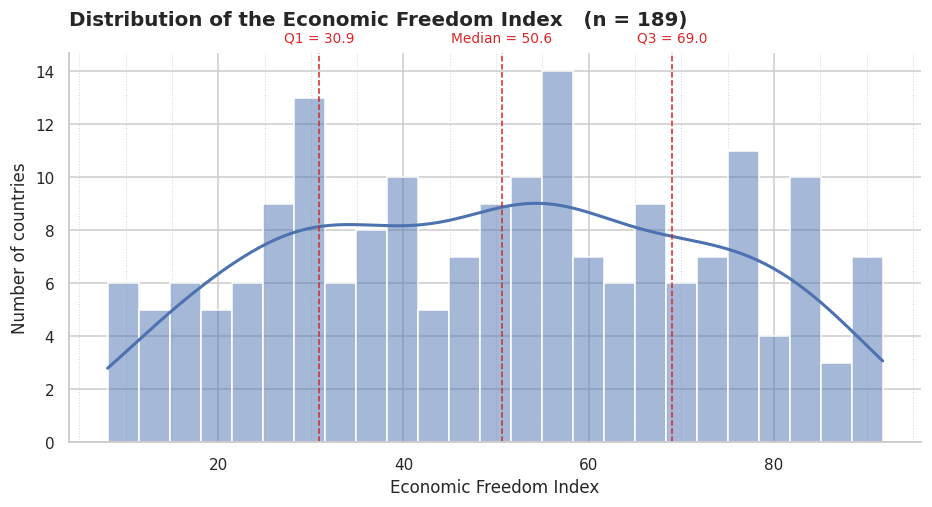

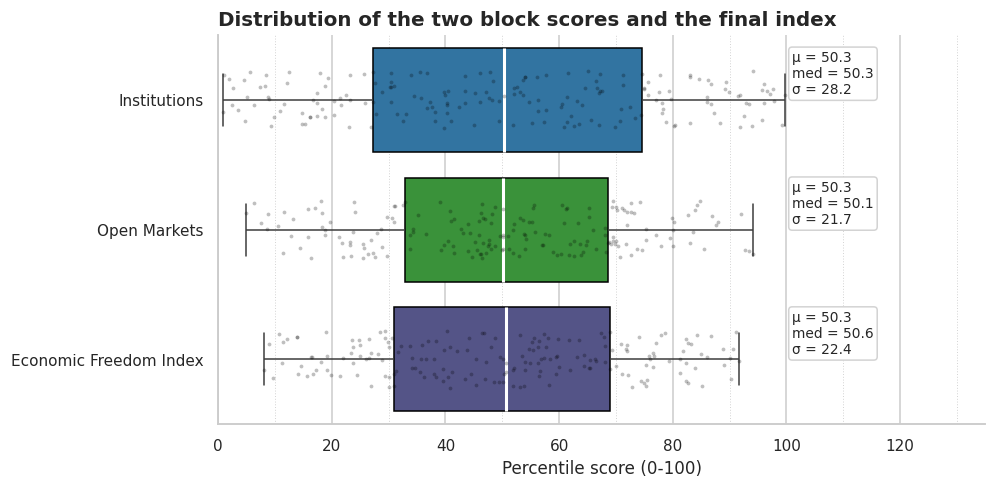

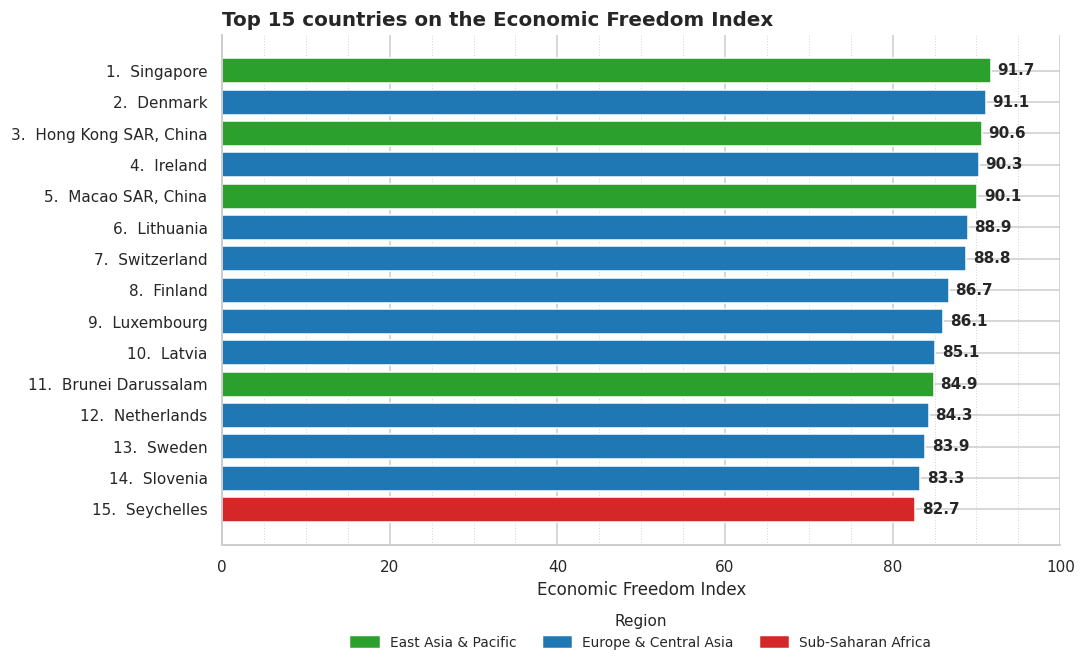

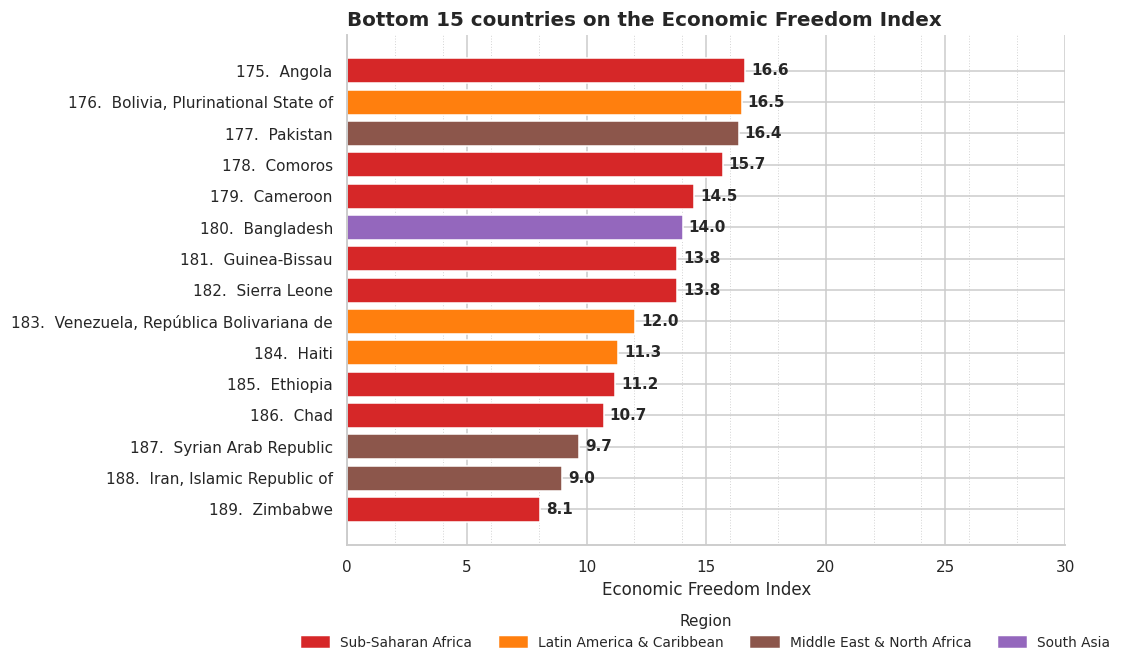

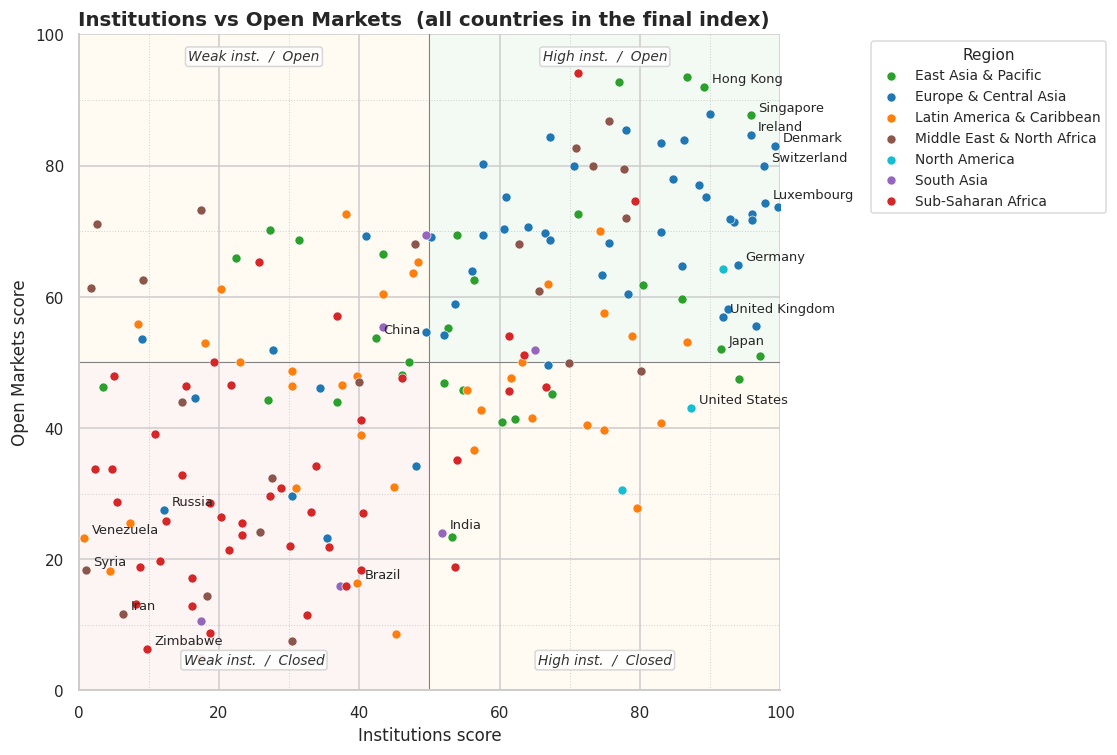

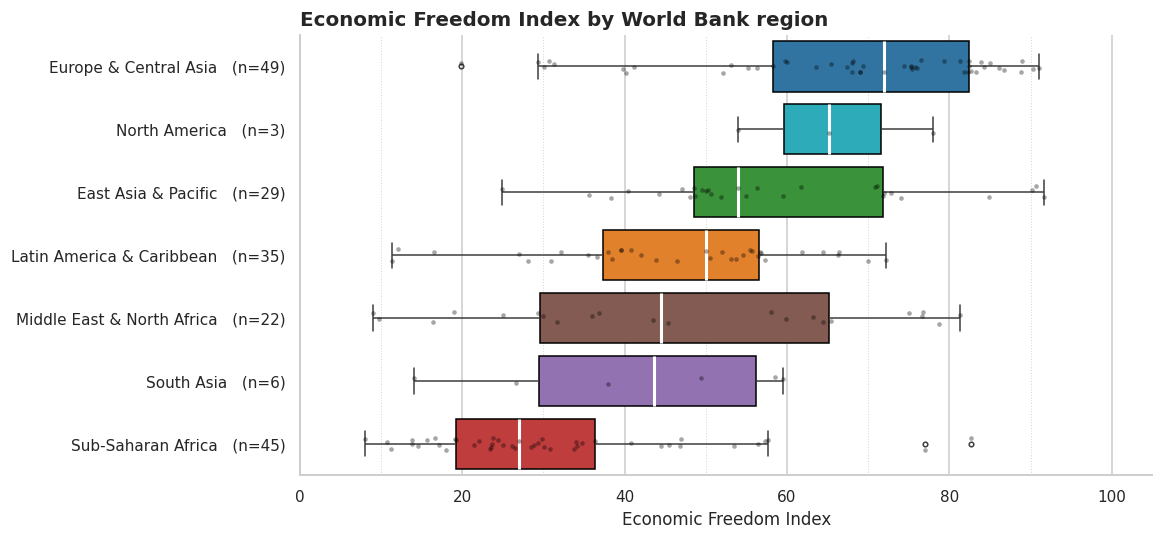

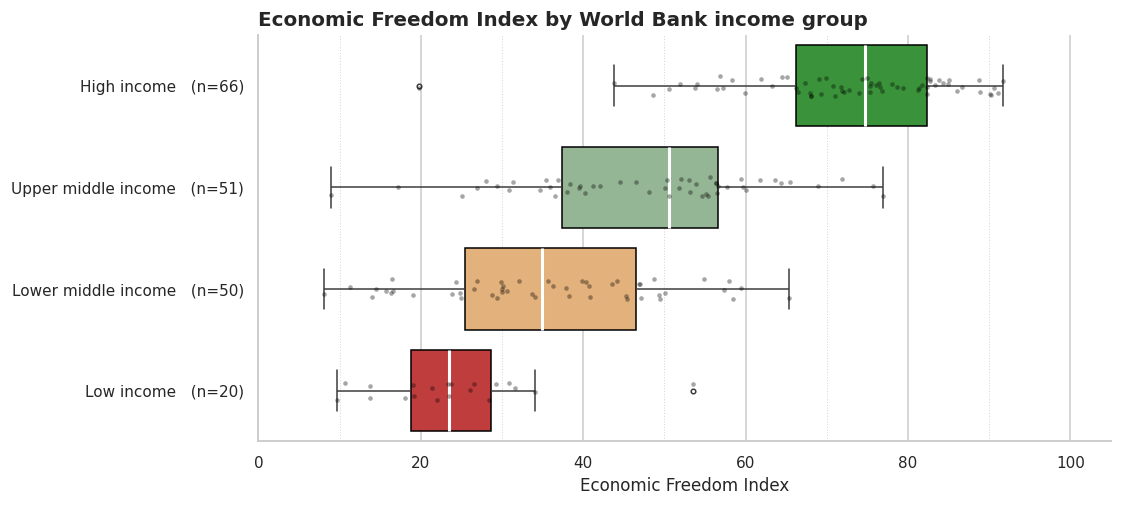

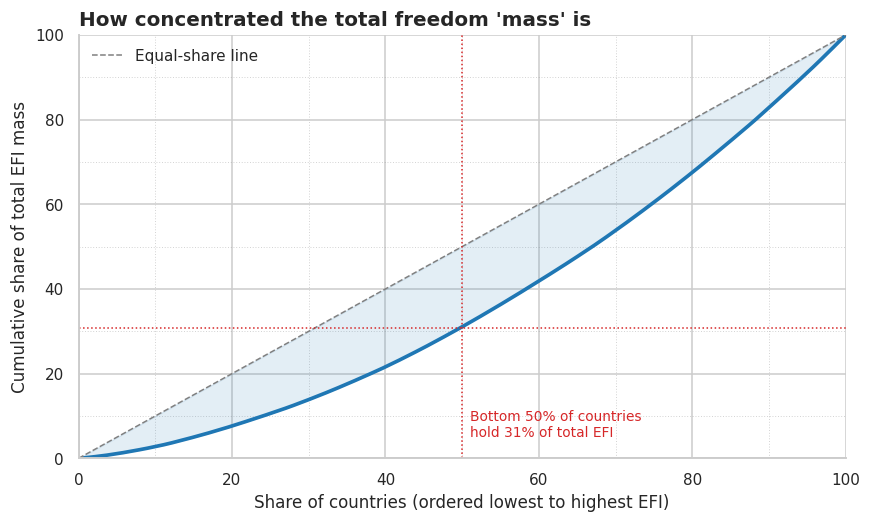

In [19]:
# ---- Distribution of the final index ----------------------------------------
_s = final_ranking["Economic Freedom Index"]
fig, ax = plt.subplots(figsize=(10, 4.6))
sns.histplot(_s, bins=25, kde=True, color="#4c72b0", edgecolor="white",
             ax=ax, line_kws={"linewidth": 2})

# Quartile labels above the axes: x follows the data, y sits just above the plot,
# so they never overlap the bars or the KDE curve.
_trans = blended_transform_factory(ax.transData, ax.transAxes)
for q, lbl in zip([.25, .50, .75], ["Q1", "Median", "Q3"]):
    v = _s.quantile(q)
    ax.axvline(v, color="#d62728", linestyle="--", linewidth=1)
    ax.text(v, 1.02, f"{lbl} = {v:.1f}",
            ha="center", va="bottom", fontsize=9, color="#d62728",
            transform=_trans)

ax.set_xlabel("Economic Freedom Index")
ax.set_ylabel("Number of countries")
ax.set_title(f"Distribution of the Economic Freedom Index   (n = {len(_s)})",
             loc="left", pad=18)
add_minor_grid(ax, x_every=5)
plt.show()

# ---- Boxplot of block scores + final index ----------------------------------
_melt = final_ranking[["Institutions", "Open Markets", "Economic Freedom Index"]].melt(
    var_name="Score type", value_name="Score"
)
fig, ax = plt.subplots(figsize=(9, 4.6))
_palette = ["#1f77b4", "#2ca02c", "#4b4b8f"]
sns.boxplot(data=_melt, y="Score type", x="Score", hue="Score type",
            palette=_palette, fliersize=3, ax=ax,
            boxprops=dict(edgecolor="black"),
            medianprops=dict(color="white", linewidth=2), legend=False)
sns.stripplot(data=_melt, y="Score type", x="Score", color="black",
              alpha=.25, size=2.5, jitter=.22, ax=ax)
_stats = _melt.groupby("Score type")["Score"].agg(["mean", "median", "std"])
for i, name in enumerate(["Institutions", "Open Markets", "Economic Freedom Index"]):
    row = _stats.loc[name]
    ax.text(101, i - 0.2,
            f"μ = {row['mean']:.1f}\nmed = {row['median']:.1f}\nσ = {row['std']:.1f}",
            va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="lightgrey"))
ax.set_xlim(0, 135)
ax.set_xlabel("Percentile score (0-100)")
ax.set_ylabel("")
ax.set_title("Distribution of the two block scores and the final index", loc="left")
add_minor_grid(ax, x_every=10)
plt.show()

# ---- Top 15 -----------------------------------------------------------------
_top = final_ranking.head(15).copy()
fig, ax = plt.subplots(figsize=(10, 6.2))
_colors = [REGION_COLORS.get(r, "#666") for r in _top["Region"]]
y = np.arange(len(_top))
_bars = ax.barh(y, _top["Economic Freedom Index"], color=_colors, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels([f"{r}.  {n}" for r, n in zip(_top["Rank"], _top["Country Name"])])
ax.invert_yaxis()
ax.set_xlabel("Economic Freedom Index")
ax.set_xlim(0, 100)
for b, v in zip(_bars, _top["Economic Freedom Index"]):
    ax.text(v + 0.8, b.get_y() + b.get_height()/2,
            f"{v:.1f}", va="center", fontsize=10, fontweight="bold")
_used = _top["Region"].unique()
_handles = [plt.Rectangle((0, 0), 1, 1, color=REGION_COLORS[r]) for r in _used]
# Legend BELOW the plot, one horizontal row, so it never covers the last bars.
ax.legend(_handles, _used, loc="upper center", bbox_to_anchor=(0.5, -0.11),
          ncol=len(_used), title="Region",
          frameon=False, fontsize=9, title_fontsize=10)
ax.set_title("Top 15 countries on the Economic Freedom Index", loc="left")
add_minor_grid(ax, x_every=5)
plt.tight_layout()
plt.show()

# ---- Bottom 15 ---------------------------------------------------------------
_bot = final_ranking.tail(15).sort_values("Rank").copy()
fig, ax = plt.subplots(figsize=(10, 6.2))
_colors = [REGION_COLORS.get(r, "#666") for r in _bot["Region"]]
y = np.arange(len(_bot))
_bars = ax.barh(y, _bot["Economic Freedom Index"], color=_colors, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels([f"{r}.  {n}" for r, n in zip(_bot["Rank"], _bot["Country Name"])])
ax.invert_yaxis()
ax.set_xlabel("Economic Freedom Index")
ax.set_xlim(0, max(30, _bot["Economic Freedom Index"].max() * 1.15))
for b, v in zip(_bars, _bot["Economic Freedom Index"]):
    ax.text(v + 0.25, b.get_y() + b.get_height()/2,
            f"{v:.1f}", va="center", fontsize=10, fontweight="bold")
_used = _bot["Region"].unique()
_handles = [plt.Rectangle((0, 0), 1, 1, color=REGION_COLORS[r]) for r in _used]
ax.legend(_handles, _used, loc="upper center", bbox_to_anchor=(0.5, -0.11),
          ncol=len(_used), title="Region",
          frameon=False, fontsize=9, title_fontsize=10)
ax.set_title("Bottom 15 countries on the Economic Freedom Index", loc="left")
add_minor_grid(ax, x_every=2)
plt.tight_layout()
plt.show()

# ---- Institutions vs Open Markets quadrant scatter --------------------------
fig, ax = plt.subplots(figsize=(10.5, 7))
mx, my = 50, 50
ax.add_patch(Rectangle((mx, my), 100 - mx, 100 - my, color="#e8f5e8", alpha=.5, zorder=0))
ax.add_patch(Rectangle((0, my), mx, 100 - my, color="#fff7e6", alpha=.5, zorder=0))
ax.add_patch(Rectangle((mx, 0), 100 - mx, my, color="#fff7e6", alpha=.5, zorder=0))
ax.add_patch(Rectangle((0, 0), mx, my, color="#fdeaea", alpha=.5, zorder=0))
ax.axvline(mx, color="grey", linewidth=.7, zorder=1)
ax.axhline(my, color="grey", linewidth=.7, zorder=1)
for reg, g in final_ranking.groupby("Region"):
    ax.scatter(g["Institutions"], g["Open Markets"],
               s=35, color=REGION_COLORS.get(reg, "#666"),
               label=reg, edgecolor="white", linewidth=.4, zorder=3)
_short = {"Hong Kong SAR, China": "Hong Kong",
          "Venezuela, República Bolivariana de": "Venezuela",
          "Iran, Islamic Republic of": "Iran",
          "Syrian Arab Republic": "Syria",
          "Russian Federation": "Russia"}
_hi = ["Singapore", "Denmark", "Hong Kong SAR, China", "Ireland", "Luxembourg",
       "United States", "United Kingdom", "Japan", "Germany", "Switzerland",
       "Brazil", "India", "China", "Russian Federation",
       "Venezuela, República Bolivariana de", "Zimbabwe",
       "Iran, Islamic Republic of", "Syrian Arab Republic"]
for _, r in final_ranking[final_ranking["Country Name"].isin(_hi)].iterrows():
    n = _short.get(r["Country Name"], r["Country Name"])
    ax.annotate(n, (r["Institutions"], r["Open Markets"]),
                fontsize=8.5, xytext=(5, 3), textcoords="offset points")
for x, y, t in [(75, 96, "High inst.  /  Open"),
                (25, 96, "Weak inst.  /  Open"),
                (75, 4,  "High inst.  /  Closed"),
                (25, 4,  "Weak inst.  /  Closed")]:
    ax.text(x, y, t, ha="center", fontsize=9, style="italic", color="#333",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor="lightgrey", alpha=.9))
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("Institutions score"); ax.set_ylabel("Open Markets score")
ax.set_title("Institutions vs Open Markets  (all countries in the final index)",
             loc="left")
# Legend outside the axes (right side) so it never covers data.
ax.legend(title="Region", loc="upper left", bbox_to_anchor=(1.12, 1),
          fontsize=9, title_fontsize=10, frameon=True,
          facecolor="white", edgecolor="lightgrey")
add_minor_grid(ax, x_every=10, y_every=10)
plt.tight_layout()
plt.show()

# ---- Regional breakdown ------------------------------------------------------
_region_order = (final_ranking.groupby("Region")["Economic Freedom Index"].median()
                              .sort_values(ascending=False).index.tolist())
_counts = final_ranking["Region"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.boxplot(data=final_ranking, y="Region", x="Economic Freedom Index",
            order=_region_order, hue="Region",
            palette={r: REGION_COLORS[r] for r in _region_order},
            fliersize=3, ax=ax,
            boxprops=dict(edgecolor="black"),
            medianprops=dict(color="white", linewidth=2), legend=False)
sns.stripplot(data=final_ranking, y="Region", x="Economic Freedom Index",
              order=_region_order, color="black", alpha=.35, size=3, ax=ax)
ax.set_yticks(range(len(_region_order)))
ax.set_yticklabels([f"{r}   (n={_counts[r]})" for r in _region_order])
ax.set_xlim(0, 105)
ax.set_xlabel("Economic Freedom Index"); ax.set_ylabel("")
ax.set_title("Economic Freedom Index by World Bank region", loc="left")
add_minor_grid(ax, x_every=10)
plt.show()

# ---- Income group breakdown --------------------------------------------------
_inc_df = final_ranking[final_ranking["Income Group"] != "Not reported in WDICountry.csv"].copy()
_inc_order = ["High income", "Upper middle income", "Lower middle income", "Low income"]
_inc_order = [o for o in _inc_order if o in _inc_df["Income Group"].unique()]
_inc_counts = _inc_df["Income Group"].value_counts()
_inc_pal = {"High income": "#2ca02c", "Upper middle income": "#8fbc8f",
            "Lower middle income": "#f4b26a", "Low income": "#d62728"}
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(data=_inc_df, y="Income Group", x="Economic Freedom Index",
            order=_inc_order, hue="Income Group",
            palette={o: _inc_pal[o] for o in _inc_order},
            fliersize=3, ax=ax,
            boxprops=dict(edgecolor="black"),
            medianprops=dict(color="white", linewidth=2), legend=False)
sns.stripplot(data=_inc_df, y="Income Group", x="Economic Freedom Index",
              order=_inc_order, color="black", alpha=.35, size=3, ax=ax)
ax.set_yticks(range(len(_inc_order)))
ax.set_yticklabels([f"{o}   (n={_inc_counts[o]})" for o in _inc_order])
ax.set_xlim(0, 105)
ax.set_xlabel("Economic Freedom Index"); ax.set_ylabel("")
ax.set_title("Economic Freedom Index by World Bank income group", loc="left")
add_minor_grid(ax, x_every=10)
plt.show()

# ---- Lorenz-style cumulative concentration ----------------------------------
_d = final_ranking.sort_values("Economic Freedom Index").reset_index(drop=True)
_d["country_rank_pct"] = np.arange(1, len(_d) + 1) / len(_d) * 100
_cum = _d["Economic Freedom Index"].cumsum()
_d["efi_cum_pct"] = _cum / _cum.iloc[-1] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(_d["country_rank_pct"], _d["efi_cum_pct"], color="#1f77b4", linewidth=2.4)
ax.plot([0, 100], [0, 100], "--", color="grey", linewidth=1, label="Equal-share line")
ax.fill_between(_d["country_rank_pct"], _d["efi_cum_pct"], _d["country_rank_pct"],
                alpha=.12, color="#1f77b4")
_p50 = _d.loc[_d["country_rank_pct"] <= 50, "efi_cum_pct"].iloc[-1]
ax.axvline(50, color="#d62728", linestyle=":", linewidth=1)
ax.axhline(_p50, color="#d62728", linestyle=":", linewidth=1)
ax.text(51, 5, f"Bottom 50% of countries\nhold {_p50:.0f}% of total EFI",
        fontsize=9, color="#d62728")
ax.set_xlabel("Share of countries (ordered lowest to highest EFI)")
ax.set_ylabel("Cumulative share of total EFI mass")
ax.set_title("How concentrated the total freedom 'mass' is", loc="left")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc="upper left")
add_minor_grid(ax, x_every=10, y_every=10)
plt.show()


In [16]:
final_ranking.to_csv("economic_freedom_ranking.csv", index=False)

print("Rows in final ranking:", len(final_ranking))
print("Unique country codes:", final_ranking["Country Code"].nunique())
print("Missing Region values:", final_ranking["Region"].isna().sum())
print("Missing Income Group values:", final_ranking["Income Group"].isna().sum())
print("Final CSV written to economic_freedom_ranking.csv")

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(final_ranking)

Rows in final ranking: 189
Unique country codes: 189
Missing Region values: 0
Missing Income Group values: 0
Final CSV written to economic_freedom_ranking.csv


short_name,Rank,Country Name,Country Code,Region,Income Group,Institutions,Open Markets,Economic Freedom Index
0,1,Singapore,SGP,East Asia & Pacific,High income,95.77,87.65,91.71
1,2,Denmark,DNK,Europe & Central Asia,High income,99.21,82.98,91.09
2,3,"Hong Kong SAR, China",HKG,East Asia & Pacific,High income,89.15,92.06,90.61
3,4,Ireland,IRL,Europe & Central Asia,High income,95.77,84.74,90.26
4,5,"Macao SAR, China",MAC,East Asia & Pacific,High income,86.77,93.47,90.12
5,6,Lithuania,LTU,Europe & Central Asia,High income,89.95,87.92,88.93
6,7,Switzerland,CHE,Europe & Central Asia,High income,97.62,79.98,88.80
7,8,Finland,FIN,Europe & Central Asia,High income,99.74,73.63,86.68
8,9,Luxembourg,LUX,Europe & Central Asia,High income,97.88,74.25,86.07
9,10,Latvia,LVA,Europe & Central Asia,High income,86.24,83.86,85.05


## 12. Conclusion

The final notebook takes a deliberately simple route:

- start with raw WDI and WGI indicators,
- keep the latest available value up to 2024,
- remove obvious duplicates,
- use PCA, clustering, and MLR before the final index is fixed,
- keep only the parts of the structure that behave consistently,
- produce one country score that can be traced back to raw indicators.

The result is a simple two-block index:

**Economic Freedom Index = average of Institutions and Open Markets**

In [33]:
import plotly.express as px

fig = px.choropleth(
    final_ranking,
    locations="Country Code",
    color="Economic Freedom Index",
    hover_name="Country Name",
    hover_data={"Country Code": False, "Rank": True,
                "Institutions": ":.1f", "Open Markets": ":.1f",
                "Economic Freedom Index": ":.1f"},
    color_continuous_scale="RdYlGn",  # red = low freedom, green = high
    range_color=(0, 100),
    projection="natural earth",
    title="Economic Freedom Index across 189 countries",
)
fig.update_layout(
    width=980,
    height=560,
    margin=dict(l=10, r=80, t=90, b=10),
    title=dict(
        text="Economic Freedom Index across 189 countries",
        x=0.5,
        xanchor="center",
        y=0.98,
        yanchor="top",
    ),
    coloraxis_colorbar=dict(
        title=dict(text="EFI", side="top"),
        thickness=16,
        len=0.58,
        x=1,
        y=0.5,
        xanchor="left",
        yanchor="middle",
    ),
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor="#888"),
)
fig.show()